In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("train.csv")
df_test = pd.read_csv("test.csv")

In [6]:
# Now we need to perform a deep analysis on the numerical features present in our data

df.columns

Index(['id', 'road_type', 'num_lanes', 'curvature', 'speed_limit', 'lighting',
       'weather', 'road_signs_present', 'public_road', 'time_of_day',
       'holiday', 'school_season', 'num_reported_accidents', 'accident_risk'],
      dtype='object')

In [7]:
df = df.drop(columns = 'id', axis = 1)

In [8]:
df.columns

Index(['road_type', 'num_lanes', 'curvature', 'speed_limit', 'lighting',
       'weather', 'road_signs_present', 'public_road', 'time_of_day',
       'holiday', 'school_season', 'num_reported_accidents', 'accident_risk'],
      dtype='object')

In [9]:
df.select_dtypes(include = 'number')

,num_lanes,curvature,speed_limit,num_reported_accidents,accident_risk
0,2,0.06,35,1,0.13
1,4,0.99,35,0,0.35
2,4,0.63,70,2,0.30
3,4,0.07,35,1,0.21
4,1,0.58,60,1,0.56
...,...,...,...,...,...
517749,4,0.10,70,2,0.32
517750,4,0.47,35,1,0.26
517751,4,0.62,25,0,0.19
517752,3,0.63,25,3,0.51


In [10]:
numeric_cols = df.select_dtypes(include = 'number').columns.tolist()

In [11]:
numeric_cols

['num_lanes',
 'curvature',
 'speed_limit',
 'num_reported_accidents',
 'accident_risk']

In [25]:
df['num_lanes'].unique()

array([2, 4, 1, 3])

<Axes: >

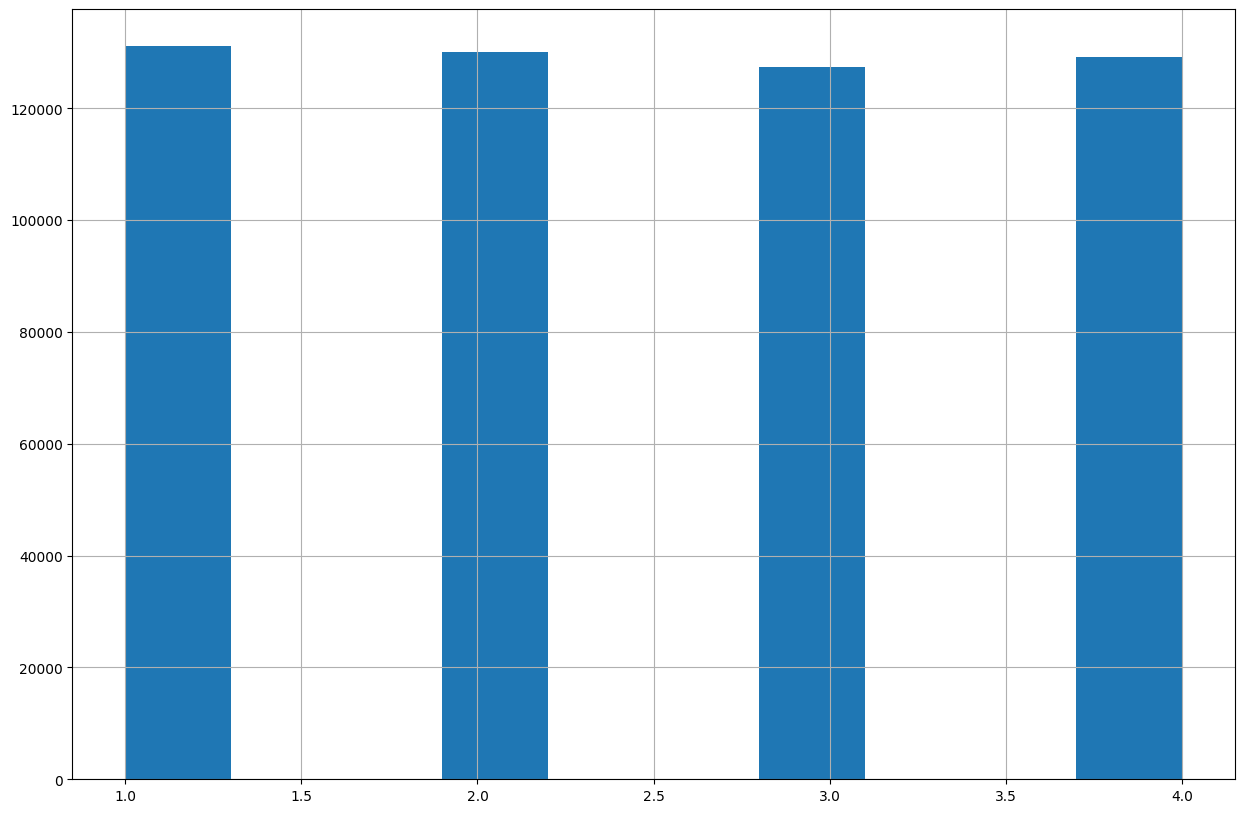

In [20]:
numeric1 = df['num_lanes']

numeric1

# whILE PERforming data preprocesing, always start off with checking what kind of distribution do they follow

# We can first check the scatter plot of this numeric column

df['num_lanes'].hist(figsize = (15,10))

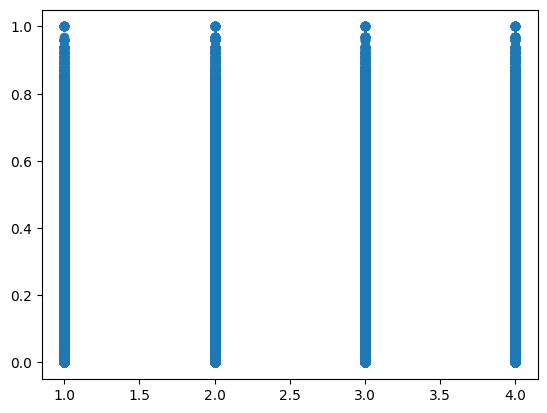

In [29]:
# Now we can check the scatter plots

plt.scatter(df['num_lanes'], df['accident_risk'])
plt.show()

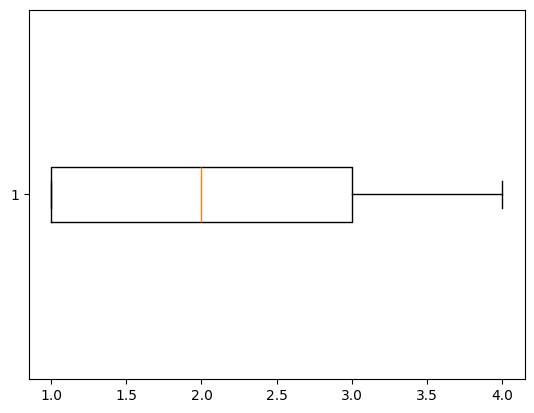

In [32]:
# Now since the above two plots could not give that much information, we can now try using the boxplot
plt.boxplot(df['num_lanes'], vert = False)
plt.show()

34731

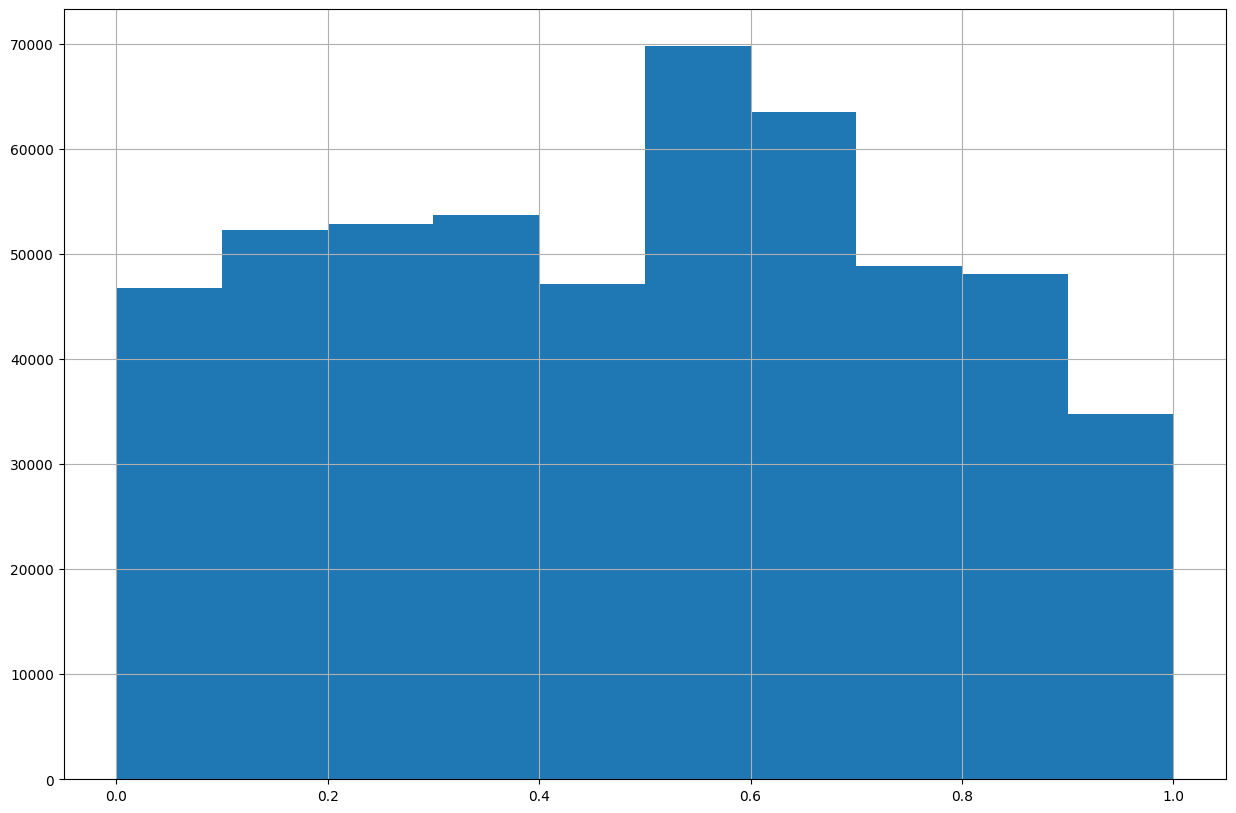

In [49]:
# As far as I could think, this column does not give that much information. We can move on to the next column.

# As we did with num_lanes, we will make a histplot for curvature

df['curvature'].hist(figsize = (15,10))

The above histplot tell us that at least this column doesn't need to be scaled as all the values are present between 0.0 and 1.0.

It also tells us that we mediocre number of straightish roads where the curvature is 0.0. Besides, we can also infer that we have very few roads that are highly curved. We have a lot of roads which have medium curvatures.

We can now bin these values into a new categorical features which is going to make the model much more powerful.



In [75]:
bins = [0.0, 0.4, 0.8, 1.0]

labels = ['low_curvature', 'medium_curvature', 'high_curvature']

df['curvature_category'] = pd.cut(df['curvature'], bins = bins, labels = labels, include_lowest = False)

In [76]:
df['curvature_category'].value_counts()

curvature_category
medium_curvature    227196
low_curvature       210940
high_curvature       78073
Name: count, dtype: int64

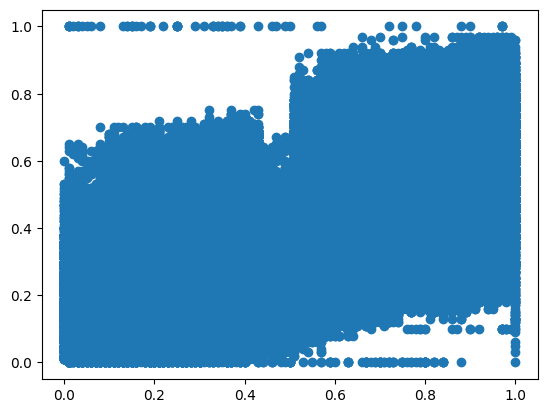

In [77]:
# Now we can move ahead the analysis that we are performing on curvature. We will now use scatterplot

plt.scatter(df['curvature'], df['accident_risk'])
plt.show()

This plot has so many curvatures between 0.2 and 0.6 and most of them have pretty low accident risk and it also makes sense for medium curvatures to have lesser number of accidents. So, one observation from this can be that since the lesser curvatures are kind of attached to lesser amount of accidents.



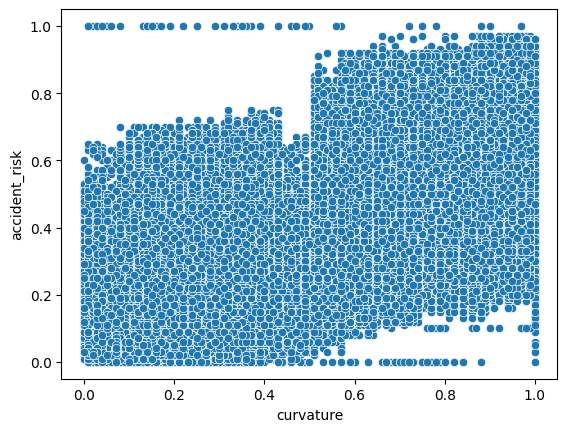

In [78]:
sns.scatterplot(x = df['curvature'], y = df['accident_risk'], data = df)
plt.show()

In [79]:
# We can investigate the few 1.0s that are present for low curvatures. They can either be flukes or they can give some good info

df_check = df.groupby('curvature_category')['accident_risk']

C:\Users\SAMIR SINHA\AppData\Local\Temp\ipykernel_23008\1237842482.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_check = df.groupby('curvature_category')['accident_risk']


In [82]:
low_curve_df = df[df['curvature_category'] == 'high'].copy()

risk = 0.5

if(len(low_curve_df) == 0.0):
    len(low_curve_df) = 1

high_risk = low_curve_df[low_curve_df['accident_risk'] >= risk]

print(len(high_risk))

high_risk_actual = (len(high_risk) / len(low_curve_df)) * 100

print(high_risk_actual)

SyntaxError: cannot assign to function call here. Maybe you meant '==' instead of '='? (3058728438.py, line 6)

212485